# Customer Retention Strategy Analysis

## Business Objective
Identify loyal customers, measure promotion dependency, build customer segments, and recommend a retention strategy for a D2C fashion brand.

### Data Cleaning

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [8]:
# Load dataset — encoding handles BOM character in column name
df = pd.read_csv("../Data/Dataset.csv", encoding='utf-8-sig')

# Strip any leading/trailing spaces from column names
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (3900, 18)

Column Names:
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']

First 3 rows:


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly


In [9]:
#Basic Overview
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"\nTotal Rows     : {df.shape[0]}")
print(f"Total Columns  : {df.shape[1]}")

print("\n--- DATA TYPES ---")
print(df.dtypes)

print("\n--- MISSING VALUES ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n--- DUPLICATES ---")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate Customer IDs: {df['Customer ID'].duplicated().sum()}")

DATASET OVERVIEW

Total Rows     : 3900
Total Columns  : 18

--- DATA TYPES ---
Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object

--- MISSING VALUES ---
               Missing Count  Missing %
Review Rating             37       0.95

--- DUPLICATES ---
Duplicate rows: 0
Duplicate Customer IDs: 0


In [10]:
# Explore Categorical Columns
cat_cols = ['Gender', 'Category', 'Season', 'Subscription Status',
            'Shipping Type', 'Discount Applied', 'Promo Code Used',
            'Payment Method', 'Frequency of Purchases', 'Size']

for col in cat_cols:
    print(f"\n[{col}]")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")


[Gender]
Gender
Male      2652
Female    1248
Name: count, dtype: int64
Unique values: 2

[Category]
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64
Unique values: 4

[Season]
Season
Spring    999
Fall      975
Winter    971
Summer    955
Name: count, dtype: int64
Unique values: 4

[Subscription Status]
Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64
Unique values: 2

[Shipping Type]
Shipping Type
Free Shipping     675
Standard          654
Store Pickup      650
Next Day Air      648
Express           646
2-Day Shipping    627
Name: count, dtype: int64
Unique values: 6

[Discount Applied]
Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64
Unique values: 2

[Promo Code Used]
Promo Code Used
No     2223
Yes    1677
Name: count, dtype: int64
Unique values: 2

[Payment Method]
Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo      

--- NUMERICAL SUMMARY ---
           Age  Purchase Amount (USD)  Review Rating  Previous Purchases
count  3900.00                3900.00        3863.00             3900.00
mean     44.07                  59.76           3.75               25.35
std      15.21                  23.69           0.72               14.45
min      18.00                  20.00           2.50                1.00
25%      31.00                  39.00           3.10               13.00
50%      44.00                  60.00           3.80               25.00
75%      57.00                  81.00           4.40               38.00
max      70.00                 100.00           5.00               50.00


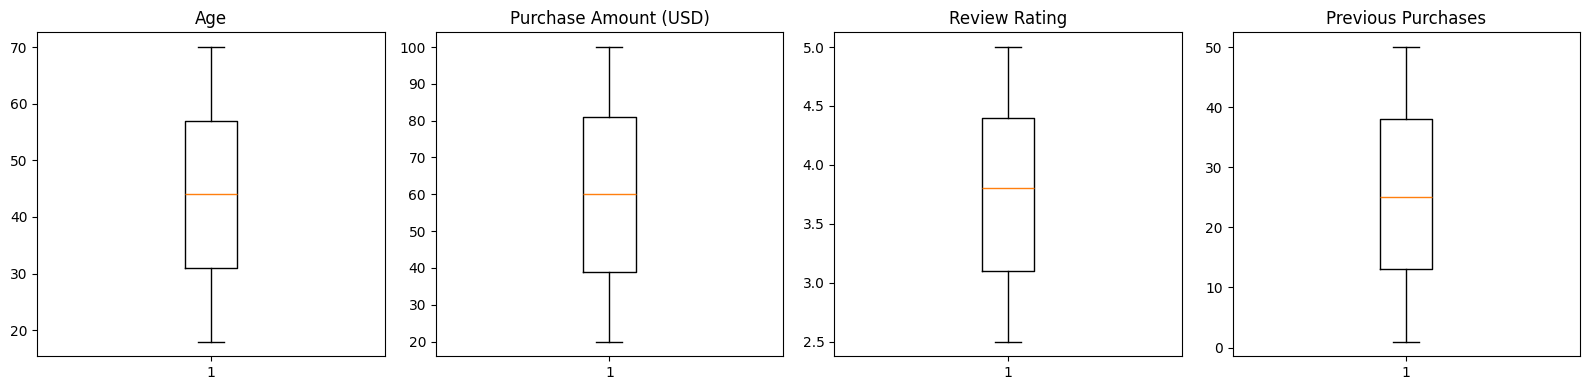

Boxplot saved


In [14]:
#Explore Numerical Columns
num_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']

print("--- NUMERICAL SUMMARY ---")
print(df[num_cols].describe().round(2))

# Check for outliers
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig("../Screenshots/numerical_boxplots.png", dpi=150)
plt.show()
print("Boxplot saved")

In [16]:
# Fix Frequency of Purchases

# Check current unique values
print("Before fix:")
print(df['Frequency of Purchases'].value_counts())

# Standardize: merge duplicate meanings
frequency_mapping = {
    'Bi-Weekly'      : 'Fortnightly',   # Both mean every 2 weeks
    'Every 3 Months' : 'Quarterly'      # Both mean 4x per year
}

df['Frequency of Purchases'] = df['Frequency of Purchases'].replace(frequency_mapping)

print("\nAfter fix:")
print(df['Frequency of Purchases'].value_counts())

Before fix:
Frequency of Purchases
Quarterly      1147
Fortnightly    1089
Annually        572
Monthly         553
Weekly          539
Name: count, dtype: int64

After fix:
Frequency of Purchases
Quarterly      1147
Fortnightly    1089
Annually        572
Monthly         553
Weekly          539
Name: count, dtype: int64


In [17]:
#Handle Missing Review Ratings
print(f"Missing Review Ratings: {df['Review Rating'].isnull().sum()}")

# Strategy: Impute with MEDIAN (not mean — ratings are ordinal-like)
median_rating = df['Review Rating'].median()
print(f"Median Rating: {median_rating}")

# Flag rows where rating was missing BEFORE imputing
df['Rating_Was_Missing'] = df['Review Rating'].isnull().astype(int)

# Impute
df['Review Rating'] = df['Review Rating'].fillna(median_rating)

print(f"Missing after imputation: {df['Review Rating'].isnull().sum()}")
print("Review Rating cleaned")

Missing Review Ratings: 37
Median Rating: 3.8
Missing after imputation: 0
Review Rating cleaned


In [18]:
# Convert Yes/No Columns to Binary (0/1)
binary_cols = ['Subscription Status', 'Discount Applied', 'Promo Code Used']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
    print(f"{col}: {df[col].value_counts().to_dict()}")

print("Binary columns converted")

Subscription Status: {0: 2847, 1: 1053}
Discount Applied: {0: 2223, 1: 1677}
Promo Code Used: {0: 2223, 1: 1677}
Binary columns converted


In [19]:
 #Check for Logical Consistency
# Check: Are there cases where Discount Applied = 1 but Promo Code Used = 0?
inconsistent = df[(df['Discount Applied'] == 1) & (df['Promo Code Used'] == 0)]
print(f"Discount Yes but Promo No: {len(inconsistent)}")

inconsistent2 = df[(df['Discount Applied'] == 0) & (df['Promo Code Used'] == 1)]
print(f"Discount No but Promo Yes: {len(inconsistent2)}")

# Note finding for documentation
print("\n📌 NOTE: If both are always identical → they are the same signal.")
print("We will use ONE combined promo flag in feature engineering.")

Discount Yes but Promo No: 0
Discount No but Promo Yes: 0

📌 NOTE: If both are always identical → they are the same signal.
We will use ONE combined promo flag in feature engineering.


In [20]:
# Validate Ranges

# Age: should be 18–70 (reasonable for a fashion brand)
print(f"Age range: {df['Age'].min()} to {df['Age'].max()}")

# Purchase Amount: should be > 0
print(f"Purchase Amount range: ${df['Purchase Amount (USD)'].min()} to ${df['Purchase Amount (USD)'].max()}")

# Previous Purchases: should be >= 0
print(f"Previous Purchases range: {df['Previous Purchases'].min()} to {df['Previous Purchases'].max()}")

# Review Rating: should be 1.0–5.0
print(f"Review Rating range: {df['Review Rating'].min()} to {df['Review Rating'].max()}")

# Flag any impossible values
df = df[df['Age'].between(10, 100)]
df = df[df['Purchase Amount (USD)'] > 0]
df = df[df['Previous Purchases'] >= 0]
df = df[df['Review Rating'].between(1.0, 5.0)]

print(f"\nRows after validation: {df.shape[0]}")
print(" Range validation complete")

Age range: 18 to 70
Purchase Amount range: $20 to $100
Previous Purchases range: 1 to 50
Review Rating range: 2.5 to 5.0

Rows after validation: 3900
 Range validation complete


In [21]:
#Rename Column for Cleanliness
df.rename(columns={
    'Purchase Amount (USD)' : 'Purchase_Amount',
    'Customer ID'           : 'Customer_ID',
    'Review Rating'         : 'Review_Rating',
    'Previous Purchases'    : 'Previous_Purchases',
    'Subscription Status'   : 'Subscription_Status',
    'Discount Applied'      : 'Discount_Applied',
    'Promo Code Used'       : 'Promo_Code_Used',
    'Shipping Type'         : 'Shipping_Type',
    'Payment Method'        : 'Payment_Method',
    'Frequency of Purchases': 'Frequency_of_Purchases',
    'Item Purchased'        : 'Item_Purchased'
}, inplace=True)

print("Columns renamed")
print(df.columns.tolist())

Columns renamed
['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category', 'Purchase_Amount', 'Location', 'Size', 'Color', 'Season', 'Review_Rating', 'Subscription_Status', 'Shipping_Type', 'Discount_Applied', 'Promo_Code_Used', 'Previous_Purchases', 'Payment_Method', 'Frequency_of_Purchases', 'Rating_Was_Missing']


In [23]:
df.to_csv('../Data/cleaned_dataset.csv', index=False)
print(f"cleaned_dataset.csv saved - Shape: {df.shape}")
print(f"cleaned_dataset.csv saved — Shape: {df.shape}")
print("\nFinal column list:")
print(df.columns.tolist())

cleaned_dataset.csv saved - Shape: (3900, 19)
cleaned_dataset.csv saved — Shape: (3900, 19)

Final column list:
['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category', 'Purchase_Amount', 'Location', 'Size', 'Color', 'Season', 'Review_Rating', 'Subscription_Status', 'Shipping_Type', 'Discount_Applied', 'Promo_Code_Used', 'Previous_Purchases', 'Payment_Method', 'Frequency_of_Purchases', 'Rating_Was_Missing']
